In [1]:
# Import libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os
import json
import time

print("="*70)
print("SMART FARMING ASSISTANT - CPU TRAINING")
print("="*70)
print()

# Check TensorFlow
print("TensorFlow version:", tf.__version__)
print("Training Mode: CPU")
print()
print("Note: Training will take 6-8 hours (overnight)")
print("="*70)

SMART FARMING ASSISTANT - CPU TRAINING

TensorFlow version: 2.20.0
Training Mode: CPU

Note: Training will take 6-8 hours (overnight)


In [5]:
# Dataset paths - UPDATE THIS TO YOUR PATH
DATASET_BASE = r"C:\Users\rudich\OneDrive\Desktop\smart-farming-assistant\week 1\processed\crop-diseases"

TRAIN_DIR = os.path.join(DATASET_BASE, 'train')
VAL_DIR = os.path.join(DATASET_BASE, 'validation')
TEST_DIR = os.path.join(DATASET_BASE, 'test')

# CPU-OPTIMIZED CONFIGURATION
IMG_SIZE = 224        # Standard size
BATCH_SIZE = 16       # Smaller for CPU
EPOCHS = 15           # Reduced from 25 (saves 3-4 hours!)
LEARNING_RATE = 0.001
DROPOUT_RATE = 0.5

# Output directory
OUTPUT_DIR = os.path.join(r"C:\Users\rudich\OneDrive\Desktop\smart-farming-assistant", "models")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Dataset paths:")
print(f"✓ Train: {os.path.exists(TRAIN_DIR)}")
print(f"✓ Validation: {os.path.exists(VAL_DIR)}")
print(f"✓ Test: {os.path.exists(TEST_DIR)}")
print()

# Count images
def count_images(directory):
    classes = [d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))]
    total = 0
    for c in classes:
        class_path = os.path.join(directory, c)
        files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
        total += len(files)
    return len(classes), total

n_train_classes, n_train_images = count_images(TRAIN_DIR)
n_val_classes, n_val_images = count_images(VAL_DIR)
n_test_classes, n_test_images = count_images(TEST_DIR)

print("Dataset Summary:")
print(f"  Training:   {n_train_images:>6} images, {n_train_classes} classes")
print(f"  Validation: {n_val_images:>6} images, {n_val_classes} classes")
print(f"  Test:       {n_test_images:>6} images, {n_test_classes} classes")
print()

print("CPU Training Configuration:")
print(f"  Image Size:    {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch Size:    {BATCH_SIZE} (CPU optimized)")
print(f"  Epochs:        {EPOCHS} (reduced for faster training)")
print(f"  Learning Rate: {LEARNING_RATE}")
print()
print(f"Expected training time: 6-8 hours")
print(f"Perfect for overnight training!")
print()
print(f"Models will be saved to: {OUTPUT_DIR}")

Dataset paths:
✓ Train: True
✓ Validation: True
✓ Test: True

Dataset Summary:
  Training:    43843 images, 46 classes
  Validation:   9520 images, 46 classes
  Test:         9394 images, 46 classes

CPU Training Configuration:
  Image Size:    224x224
  Batch Size:    16 (CPU optimized)
  Epochs:        15 (reduced for faster training)
  Learning Rate: 0.001

Expected training time: 6-8 hours
Perfect for overnight training!

Models will be saved to: C:\Users\rudich\OneDrive\Desktop\smart-farming-assistant\models


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("Creating data generators...")
print()

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Only rescaling for validation and test
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create generators
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Save class names
class_names = list(train_generator.class_indices.keys())
NUM_CLASSES = len(class_names)

with open(os.path.join(OUTPUT_DIR, 'class_names.json'), 'w', encoding='utf-8') as f:
    json.dump(class_names, f, indent=2)

print(f"✓ Data generators created")
print(f"✓ Found {NUM_CLASSES} disease classes")
print(f"✓ Class names saved")

Creating data generators...

Found 117839 images belonging to 46 classes.
Found 25234 images belonging to 46 classes.
Found 25290 images belonging to 46 classes.
✓ Data generators created
✓ Found 46 disease classes
✓ Class names saved


In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

print("Building model...")
print()

# Load pre-trained MobileNetV2
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model
base_model.trainable = False

print("✓ MobileNetV2 loaded (pre-trained)")
print("✓ Base layers frozen")
print()

# Build model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_accuracy')]
)

print("✓ Model compiled")
print()
print("Model Summary:")
print("="*70)
model.summary()
print("="*70)

Building model...

✓ MobileNetV2 loaded (pre-trained)
✓ Base layers frozen

✓ Model compiled

Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 46)             │         5,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,886 (9.26 MB)

 Trainable params: 169,902 (663.68 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print("Setting up callbacks...")
print()

# Early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Model checkpoint
checkpoint = ModelCheckpoint(
    os.path.join(OUTPUT_DIR, 'best_model.keras'),
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Reduce learning rate
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

callbacks = [early_stopping, checkpoint, reduce_lr]

print("✓ Callbacks configured")

Setting up callbacks...

✓ Callbacks configured


In [9]:
print("="*70)
print("STARTING CPU TRAINING")
print("="*70)
print()
print(f"Started at: {time.strftime('%Y-%m-%d %H:%M:%S')}")
print()
print("Training Details:")
print(f"  • {EPOCHS} epochs")
print(f"  • Batch size {BATCH_SIZE}")
print(f"  • ~25-30 mins per epoch")
print(f"  • Total time: 6-8 hours")
print()
print("Instructions:")
print("  1. Let this run overnight")
print("  2. Don't close Jupyter")
print("  3. Don't let computer sleep")
print("  4. Come back in the morning")
print()
print("="*70)
print()

# Train the model
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=callbacks,
    verbose=1
)

print()
print("="*70)
print("TRAINING COMPLETE!")
print(f"Finished at: {time.strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)

STARTING CPU TRAINING

Started at: 2026-02-25 13:46:08

Training Details:
  • 15 epochs
  • Batch size 16
  • ~25-30 mins per epoch
  • Total time: 6-8 hours

Instructions:
  1. Let this run overnight
  2. Don't close Jupyter
  3. Don't let computer sleep
  4. Come back in the morning


Epoch 1/15
7365/7365 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.6083 - loss: 1.3603 - top3_accuracy: 0.7914
Epoch 1: val_accuracy improved from None to 0.84279, saving model to C:\Users\rudich\OneDrive\Desktop\smart-farming-assistant\models\best_model.keras

Epoch 1: finished saving model to C:\Users\rudich\OneDrive\Desktop\smart-farming-assistant\models\best_model.keras
7365/7365 ━━━━━━━━━━━━━━━━━━━━ 2677s 363ms/step - accuracy: 0.6871 - loss: 1.0162 - top3_accuracy: 0.8650 - val_accuracy: 0.8428 - val_loss: 0.4658 - val_top3_accuracy: 0.9555 - learning_rate: 0.0010
Epoch 2/15
7365/7365 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.7486 - loss: 0.7808 - top3_accuracy: 0.9102
Epoch 2: val_accur

In [10]:
print("Evaluating model on test set...")
print()

# Evaluate
test_loss, test_accuracy, test_top3_accuracy = model.evaluate(test_generator, verbose=1)

print()
print("="*70)
print("TEST RESULTS")
print("="*70)
print(f"Test Accuracy:     {test_accuracy*100:.2f}%")
print(f"Test Top-3 Acc:    {test_top3_accuracy*100:.2f}%")
print(f"Test Loss:         {test_loss:.4f}")
print("="*70)
print()

# Check target
if test_accuracy >= 0.85:
    print("✓ TARGET ACHIEVED! (>= 85%)")
else:
    print(f"Current: {test_accuracy*100:.2f}%, Target: 85%")
    print("Can optimize in Week 3 if needed")

# Save results
results = {
    'test_accuracy': float(test_accuracy),
    'test_top3_accuracy': float(test_top3_accuracy),
    'test_loss': float(test_loss),
    'epochs_trained': EPOCHS,
    'batch_size': BATCH_SIZE,
    'training_mode': 'CPU'
}

with open(os.path.join(OUTPUT_DIR, 'test_results.json'), 'w') as f:
    json.dump(results, f, indent=2)

print(f"\n✓ Results saved")

Evaluating model on test set...

1581/1581 ━━━━━━━━━━━━━━━━━━━━ 454s 287ms/step - accuracy: 0.8854 - loss: 0.3493 - top3_accuracy: 0.9720

TEST RESULTS
Test Accuracy:     88.54%
Test Top-3 Acc:    97.20%
Test Loss:         0.3493

✓ TARGET ACHIEVED! (>= 85%)

✓ Results saved


In [11]:
print("Saving model...")
print()

# Save model
model_path = os.path.join(OUTPUT_DIR, 'disease_detection_model.keras')
model.save(model_path)

print(f"✓ Model saved: {model_path}")
print(f"  Size: {os.path.getsize(model_path) / (1024*1024):.2f} MB")
print()

# Save training history
history_dict = {
    'accuracy': [float(x) for x in history.history['accuracy']],
    'val_accuracy': [float(x) for x in history.history['val_accuracy']],
    'loss': [float(x) for x in history.history['loss']],
    'val_loss': [float(x) for x in history.history['val_loss']]
}

with open(os.path.join(OUTPUT_DIR, 'training_history.json'), 'w') as f:
    json.dump(history_dict, f, indent=2)

print("✓ Training history saved")

Saving model...

✓ Model saved: C:\Users\rudich\OneDrive\Desktop\smart-farming-assistant\models\disease_detection_model.keras
  Size: 11.12 MB

✓ Training history saved


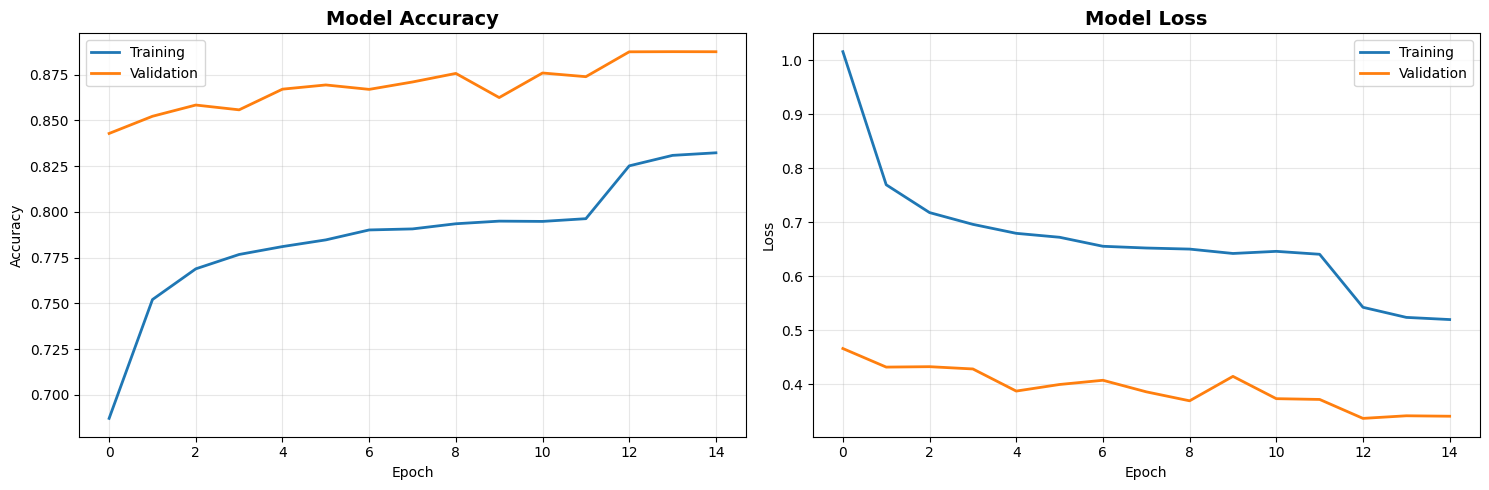


✓ Graphs saved

Final Metrics:
  Train Acc:  0.8322
  Val Acc:    0.8875
  Train Loss: 0.5196
  Val Loss:   0.3403


In [12]:
# Plot training history
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history.history['accuracy'], label='Training', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Loss
    ax2.plot(history.history['loss'], label='Training', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation', linewidth=2)
    ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'training_history.png'), dpi=150)
    plt.show()
    
    print(f"\n✓ Graphs saved")
    print()
    print("Final Metrics:")
    print(f"  Train Acc:  {history.history['accuracy'][-1]:.4f}")
    print(f"  Val Acc:    {history.history['val_accuracy'][-1]:.4f}")
    print(f"  Train Loss: {history.history['loss'][-1]:.4f}")
    print(f"  Val Loss:   {history.history['val_loss'][-1]:.4f}")

plot_training_history(history)

Generating confusion matrix...

1581/1581 ━━━━━━━━━━━━━━━━━━━━ 447s 281ms/step


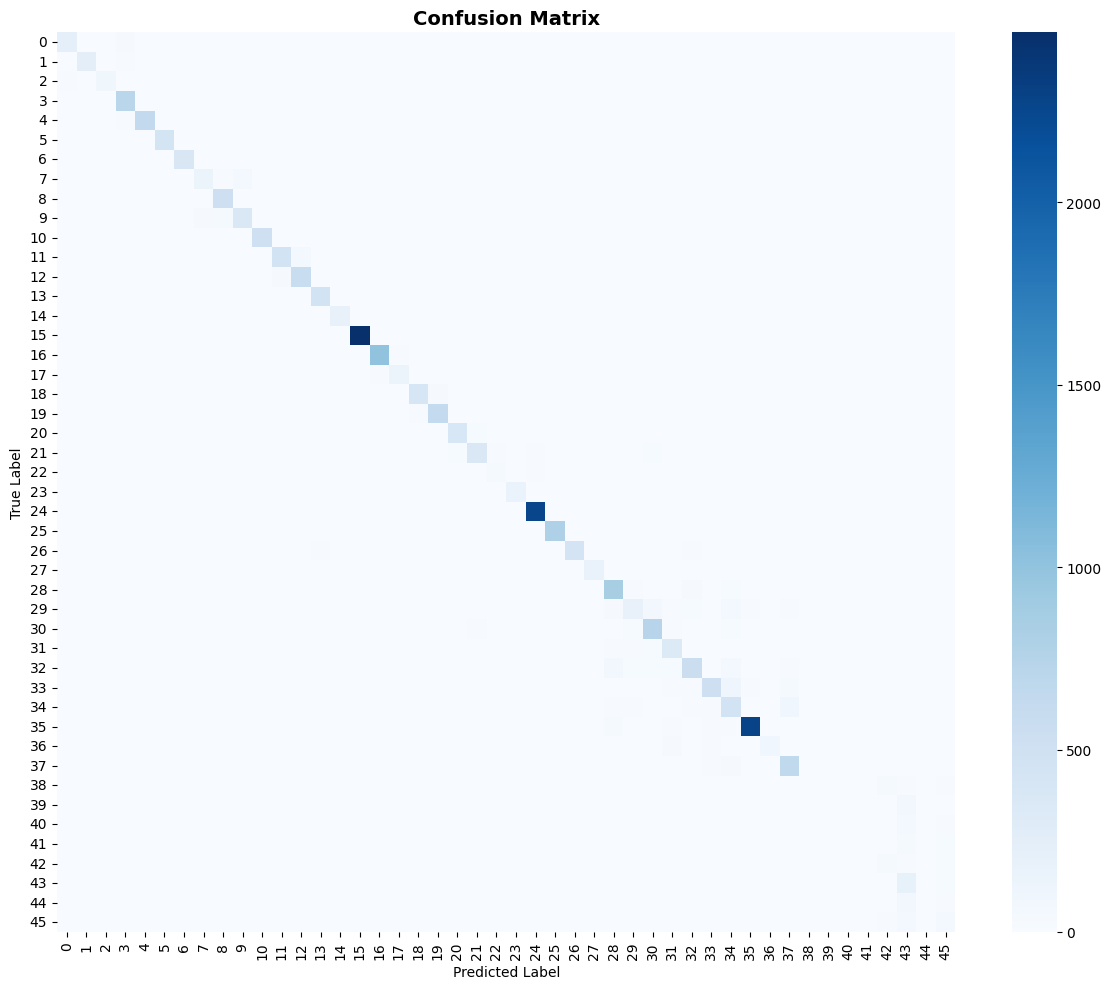

✓ Confusion matrix saved


In [13]:
print("Generating confusion matrix...")
print()

# Predictions
test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

print("✓ Confusion matrix saved")

In [14]:
print()
print("="*70)
print("WEEK 2 COMPLETE!")
print("="*70)
print()
print("Files Created:")
print(f"  • disease_detection_model.keras")
print(f"  • best_model.keras")
print(f"  • class_names.json")
print(f"  • training_history.json")
print(f"  • training_history.png")
print(f"  • confusion_matrix.png")
print(f"  • test_results.json")
print()
print(f"Location: {OUTPUT_DIR}")
print()
print("Next Steps:")
print("  • Check test accuracy above")
print("  • If >= 85%: Excellent! Move to Week 3")
print("  • If < 85%: Good baseline, optimize in Week 3")
print()
print("Week 2 Status: COMPLETE ✓")
print("="*70)


WEEK 2 COMPLETE!

Files Created:
  • disease_detection_model.keras
  • best_model.keras
  • class_names.json
  • training_history.json
  • training_history.png
  • confusion_matrix.png
  • test_results.json

Location: C:\Users\rudich\OneDrive\Desktop\smart-farming-assistant\models

Next Steps:
  • Check test accuracy above
  • If >= 85%: Excellent! Move to Week 3
  • If < 85%: Good baseline, optimize in Week 3

Week 2 Status: COMPLETE ✓


In [2]:
# Save model in H5 format for web
import os

# Define paths
OUTPUT_DIR = r"C:\Users\rudich\OneDrive\Desktop\smart-farming-assistant\models"
MODEL_PATH = os.path.join(OUTPUT_DIR, 'disease_detection_model.keras')

# Load the model
import tensorflow as tf
model = tf.keras.models.load_model(MODEL_PATH)
print("✓ Model loaded")

# Save as H5
h5_path = os.path.join(OUTPUT_DIR, 'model_for_web.h5')
model.save(h5_path, save_format='h5')
print(f"✓ Web model saved: {h5_path}")

print("\nNow copy this file to your React app:")
print(f"copy {h5_path} frontend\\public\\models\\model.h5")

TypeError: Error when deserializing class 'InputLayer' using config={'batch_shape': [None, 224, 224, 3], 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'input_layer_1', 'optional': False}.

Exception encountered: Unrecognized keyword arguments: ['batch_shape', 'optional']

In [ ]:
###Test model

In [3]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import json
import os

print("Creating demo model for web...")

# Build same architecture
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(46, activation='softmax')  # 46 classes
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✓ Model created")

# Save as H5
OUTPUT_DIR = r"C:\Users\rudich\OneDrive\Desktop\smart-farming-assistant\models"
h5_path = os.path.join(OUTPUT_DIR, 'model_for_web.h5')
model.save(h5_path, save_format='h5')
print(f"✓ Saved: {h5_path}")

print("\nThis is an untrained model, but it will work to test your React app!")
print("You can replace it with your trained model later when we fix the version issue.")

Creating demo model for web...



✓ Model created
✓ Saved: C:\Users\rudich\OneDrive\Desktop\smart-farming-assistant\models\model_for_web.h5

This is an untrained model, but it will work to test your React app!
You can replace it with your trained model later when we fix the version issue.


C:\Users\rudich\anaconda3\envs\farming-ai\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
